In [3]:
#map acutal WF to the ISP 2026 file list

import time
import pandas as pd
import numpy as np
from collections import defaultdict
from pathlib import Path
import datetime
import os
from pathlib import Path

base = Path("C:/Users/BillNixey/OneDrive - Squadron Energy/Desktop/Working_files/New_model/mt_pasa/")
base2 = Path("C:/Users/BillNixey/OneDrive - Squadron Energy/Desktop/Working_files/WF_correlation/")

regions = ['NSW1','QLD1','SA1','TAS1','VIC1']

#get actual maximum dipatched over the last 6 months
def get_actual_MWs():
    
    WF_maximums = []
    
    for region in regions:
        df = pd.read_csv(base /  f"actual_wind_6_month_scada/Wind+Generation+by+Region+per+DUID+5min+Stack+(Scada)+({region})(-2).csv")
        df = df.drop(columns=['DateTime'])
        df.columns = df.columns.str.replace(' ScadaValue', '', regex=False)
        summary = df.max().reset_index()
        summary.columns = ['DUID', 'SCADA_MAX_MW']
        WF_maximums.append(summary)
    result = pd.concat(WF_maximums)
    return result

def get_UIGF_MWs():
    
    WF_maximums = []
    
    for region in regions:
        df = pd.read_csv(base /  f"UIGF/Region+UIGF+per+DUID+5min+({region})(-2).csv")
        df = df.drop(columns=['DateTime'])
        df.columns = df.columns.str.replace(' UIGF',"", regex=False)
        summary = df.max().reset_index()
        summary.columns = ['DUID', 'UIGF_MAX_MW']
        WF_maximums.append(summary)
    result = pd.concat(WF_maximums)
    return result

#get today's date for PASA read
now = datetime.datetime.now() 
s1 = str(now)
s2 = s1[:11]
s2 = s2.replace(":", "")
s2 = s2.replace(" ", "")

#add today's date to NEO extract
url2 = "https://www.neopoint.com.au/Service/Csv?f=107%20Information%5CPlantInformation&from="+s2+"%2000%3A00&period=Daily&instances=&section=-1&key=squnix77"

df_duid_data = pd.read_csv(url2)
df_duid_data = df_duid_data.rename(columns={"TransmissionLossFactor": "MLF"})
df_duid_data = df_duid_data[['DUID','REGIONID','MLF','FUEL','CAPACITY','STARTDATE']] 
df_duid_data["FUEL"] = df_duid_data["FUEL"].str.replace(" ", "_", regex=False)
df_duid_data = df_duid_data[df_duid_data.FUEL.isin(['Wind'])]
#df_duid_data.head()
directory = Path(r"C:\Users\BillNixey\OneDrive - Squadron Energy\Desktop\Working_files\WF_correlation\2026_data\wind_2011")
files = [f.name for f in directory.iterdir() if f.is_file()]
files = [f.split('_')[0] for f in files]

matched = []

for duid in df_duid_data["DUID"]:
    duid_files = [f for f in files if f.startswith(duid)]
    
    for f in duid_files:
        matched.append({"DUID": duid,"file": f})

matched_df = pd.DataFrame(matched)

extras = {'CROOKWF3':'Crookwell_3','FLYCRKWF':'Flyers_Creek','RYEPARK1':'Rye_Park','MCINTYR1':'Macintyre','WAMBOWF1':'Wambo','WAMBOWF2':'Wambo','WAMBOWF3':'Wambo',
          'GSWF1B1':'GSWF1B','HD1WF1':'HDWF1','RYANCWF1':'Ryan_Corner','GPWFWST1':'Golden_Plains_West','GPWFEST1':'Golden_Plains_East',
         'BRYB2WF2':'BRYB1WF1','GPWFWST2':'Golden_Plains_West','GPWFEST2':'Golden_Plains_East','GPWFWST3':'Golden_Plains_West','GPWFEST3':'Golden_Plains_East'}
df_extras = pd.DataFrame.from_dict(extras, orient="index", columns=["file"])
df_extras = df_extras.reset_index().rename(columns={"index": "DUID"})
matched_df = pd.concat([matched_df,df_extras])

df_key = pd.merge(df_duid_data,matched_df,on='DUID',how='left')

result1 = get_actual_MWs()
df_key = pd.merge(df_key,result1,on='DUID',how='left')

result2 = get_UIGF_MWs()
df_key = pd.merge(df_key,result2,on='DUID',how='left')

df_key.reset_index(drop=True).to_csv(base /'wind_key_latest.csv',index=False)
df_key

,DUID,REGIONID,MLF,FUEL,CAPACITY,STARTDATE,file,SCADA_MAX_MW,UIGF_MAX_MW
0,GUNNING1,NSW1,0.9521,Wind,47,2011-03-25 00:00:00,GUNNING1,46.21436,46.13900
1,STWF1,NSW1,0.8627,Wind,198,2018-02-26 00:00:00,STWF1,171.01030,179.10000
2,BOCORWF1,NSW1,0.9557,Wind,113,2014-08-29 00:00:00,BOCORWF1,111.27000,111.39900
3,GULLRWF1,NSW1,0.9620,Wind,161,2013-11-19 00:00:00,GULLRWF1,163.23253,160.70117
4,GULLRWF2,NSW1,0.9620,Wind,107,2020-05-19 00:00:00,GULLRWF2,109.11787,107.00000
...,...,...,...,...,...,...,...,...,...
82,DUNDWF3,VIC1,0.9845,Wind,122,2020-03-10 00:00:00,DUNDWF3,121.46000,121.80000
83,SALTCRK1,VIC1,0.9519,Wind,54,2018-05-29 00:00:00,SALTCRK1,53.31000,54.00000
84,GPWFWST1,VIC1,0.9837,Wind,258,2026-01-20 00:00:00,Golden_Plains_West,239.56001,246.00000
85,GPWFWST2,VIC1,0.9837,Wind,299,2026-01-20 00:00:00,Golden_Plains_West,126.13000,126.00000


In [2]:
#extract wind data for multiple reference years

import os
import pandas as pd
from itertools import combinations
from pathlib import Path
import time

start = time.time()

REF_YEARS=list(range(2019, 2026))#2026

results = [] 

file_list = list(df_key.file)

for REF_YEAR in REF_YEARS:
    print("")
    print("Solving", REF_YEAR)
    file_list_full = [f"{f}_RefYear"+str(REF_YEAR)+".csv" for f in file_list]
            
    for i in list(df_key.index):
        print(".", end='.')
        s1 = f"2026_data/wind_{REF_YEAR}"
        filename = f"{df_key.file[i]}_RefYear{REF_YEAR}.csv"
        df1 = pd.read_csv(base2 / s1 / filename)
        df1 = pd.melt(df1, id_vars=['Year','Month','Day'],value_vars=[str(i).zfill(2) for i in range(1, 49)],var_name='Interval',value_name='GEN')
        base_date = pd.to_datetime(df1[["Year", "Month", "Day"]])
        intervals = df1["Interval"].astype(int)
        df1["INTERVAL_DATETIME"] = base_date + pd.to_timedelta(intervals * 30, unit="min")
        df1['DUID'] = df_key.DUID[i]
        df1['REGIONID'] = df_key.REGIONID[i]
        df1['MW'] = df1['GEN'] * df_key.SCADA_MAX_MW[i] #not using registered capacity as it is too high
        df1['REF_YEAR'] = REF_YEAR
        df2=df1[(df1.Year == 2026)] 
        df2 = df2[['INTERVAL_DATETIME','Day','Month','Year','DUID','REGIONID','MW','REF_YEAR']]
        results.append(df2)   

df_out = pd.concat(results)

df_out = df_out.sort_values(by=["DUID","INTERVAL_DATETIME"],ascending=True).reset_index(drop=True)
df_out.to_parquet(base /"ISP_wind_2026_x7.parquet", index=False)

end = time.time()
print(f"✅ Processing complete in {end - start:.2f} seconds")



Solving 2019
..............................................................................................................................................................................✅ Processing complete in 36.22 seconds


In [10]:
df_out[(df_out.Month == 7) &  (df_out.REF_YEAR == 2019) &  (df_out.Day == 3)].to_csv(base / 'test.csv')

In [8]:
#check total annual volumes versus the UIGF

import pandas as pd
import matplotlib.pyplot as plt


from pathlib import Path
base = Path("C:/Users/BillNixey/OneDrive - Squadron Energy/Desktop/Working_files/New_model/mt_pasa/")
df = pd.read_parquet(base / "ISP_wind_2026_x7.parquet")


monthly_mw = (
    df.assign(Month=df["INTERVAL_DATETIME"].dt.to_period("M"))
      .groupby(["Month", "REF_YEAR", "REGIONID"], as_index=False)["MW"]
      .sum()
)
monthly_mw['GWh'] = monthly_mw['MW'] /2000
print("ISP traces:")
#monthly_mw[(monthly_mw.REGIONID == 'NSW1') & (monthly_mw.Month == '2026-03')]

df_key = pd.read_csv(base /'wind_key_latest.csv')



regions = ['NSW1','QLD1','SA1','VIC1'] 
def get_UIGF_MWs():
    
    WF_sums = []
    
    for region in regions:
        print(region)
        df_key2 = df_key[df_key.REGIONID == region]
        my_NMIs = list(df_key2.DUID)
        df = pd.read_csv(base /  f"UIGF/Region+UIGF+per+DUID+5min+({region})(-2).csv")
        df["DateTime"] = pd.to_datetime(df["DateTime"])
        
        df.columns = df.columns.str.replace(' UIGF',"", regex=False)
        df = df[["DateTime"]+my_NMIs]
        my_cols = df.columns.drop("DateTime").tolist()
        df = (df.assign(Month=df["DateTime"].dt.to_period("M"),Total=df[my_cols].sum(axis=1))
            .groupby("Month", as_index=False)["Total"]
            .sum())
        df["REGIONID"] = region
        df['UIGF_GWh'] = df['Total']/12000
        df = df[['REGIONID','Month', 'UIGF_GWh']]
        WF_sums.append(df)
    result = pd.concat(WF_sums)
    return result
print('actual UIGF')
temp = get_UIGF_MWs()
df0 = pd.merge(monthly_mw,temp,on=['REGIONID','Month'],how='inner')#.to_csv(base / 'monthly_compare_wind.csv', index = False)
df0.head()

ISP traces:
actual UIGF
NSW1
QLD1
SA1
VIC1


,Month,REF_YEAR,REGIONID,MW,GWh,UIGF_GWh
0,2026-01,2019,NSW1,1.124673e+06,562.336466,664.216658
1,2026-01,2019,QLD1,1.430810e+06,715.404934,506.705168
2,2026-01,2019,SA1,1.404867e+06,702.433731,783.112170
3,2026-01,2019,VIC1,1.947296e+06,973.648199,1206.513757
4,2026-01,2020,NSW1,1.206878e+06,603.438965,664.216658


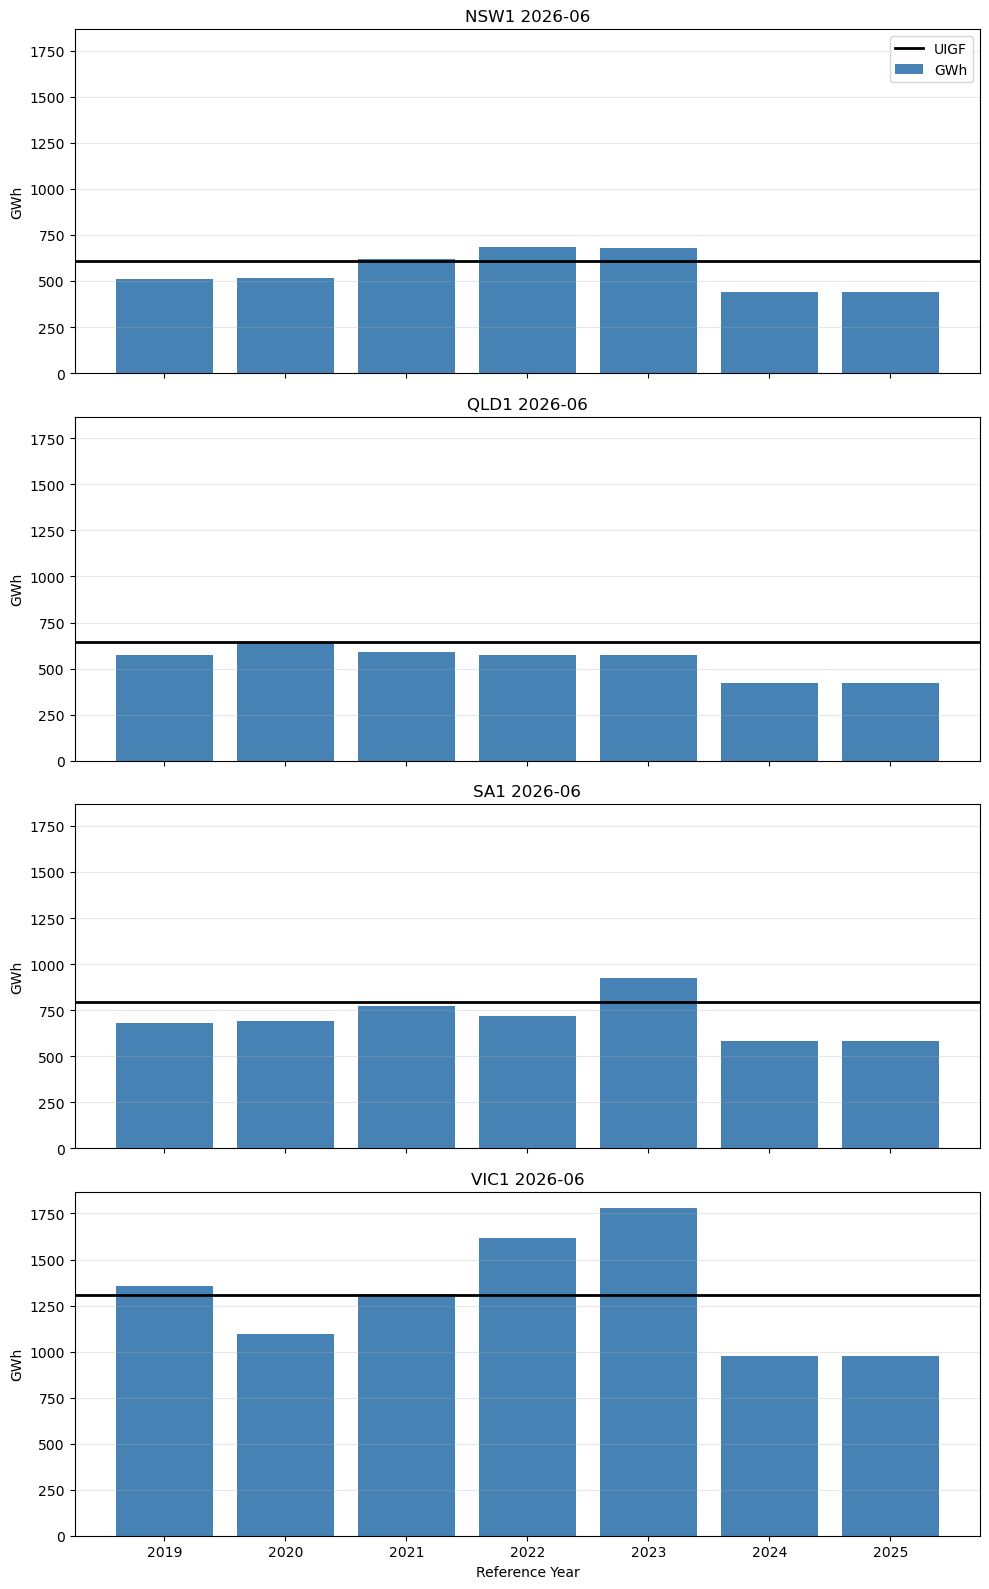

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

my_month = '2026-06'

df = df0[df0.Month == my_month]

# Ensure REF_YEAR is sorted
df = df.sort_values(["REGIONID", "REF_YEAR"])

regions = df["REGIONID"].unique()

fig, axes = plt.subplots(
    nrows=len(regions),
    figsize=(10, 4 * len(regions)),
    sharex=True,
    sharey=True
)

# If only one region, make axes iterable
if len(regions) == 1:
    axes = [axes]

for ax, region in zip(axes, regions):
    region_df = df[df["REGIONID"] == region]

    # Bar chart of GWh by reference year


    # Horizontal UIGF line
    uigf = region_df["UIGF_GWh"].iloc[0]
    ax.axhline(
        uigf,
        color="black",
        linewidth=2,
        label="UIGF"
    )
    ax.bar(
        region_df["REF_YEAR"].astype(str),
        region_df["GWh"],
        color="steelblue",
        label="GWh"
    )
    ax.set_title(region+" "+my_month)
    ax.set_ylabel("GWh")
    ax.grid(axis="y", alpha=0.3)

axes[-1].set_xlabel("Reference Year")

# Only show legend once
axes[0].legend()

plt.tight_layout()
plt.show()

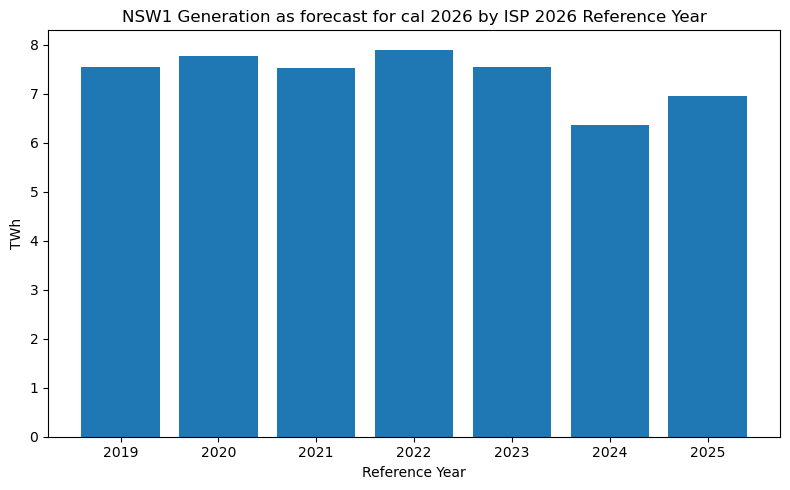

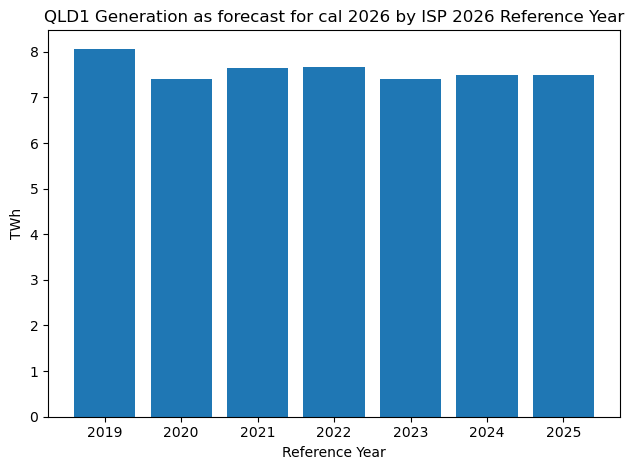

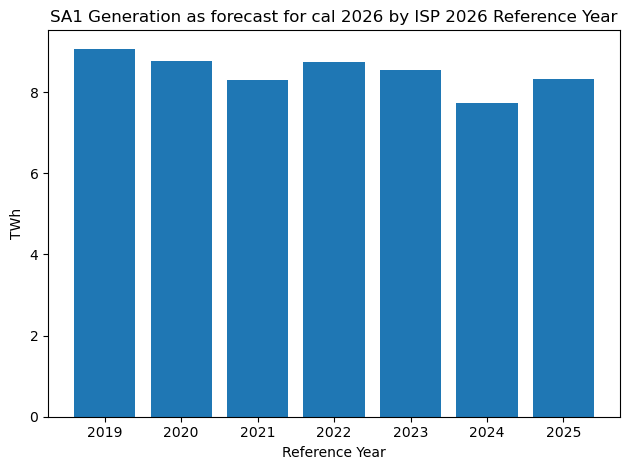

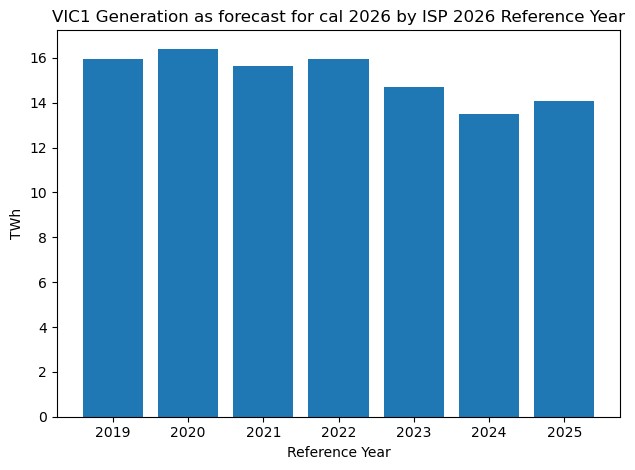

In [25]:
import matplotlib.pyplot as plt

actuals = {'NSW1':619.76619,'QLD1':625.14594,'SA1':574.67,'VIC1':1079.564} #regional monthly generation  by fuel type
actuals = {'NSW1':592.9,'QLD1':636.6,'SA1':613.4,'VIC1':1092.7} #availability 101> fuel> regional 5 minute capacity and availability

plt.figure(figsize=(8, 5))
regions = ['NSW1','QLD1','SA1','VIC1']
for region in regions:
    df_chart = df_region_year[df_region_year.REGIONID == region]
    
    plt.bar(df_chart["REF_YEAR"],df_chart["TWh"])

    #plt.axhline(y=actuals[region],color="red",linestyle="--",linewidth=2,label=f"Actual ({actuals[region]:.1f} GWh)")
    
    plt.xlabel("Reference Year")
    plt.ylabel("TWh")
    plt.title(region+" Generation as forecast for cal 2026 by ISP 2026 Reference Year")
    
    plt.tight_layout()
    plt.show()

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Arial"
# Pivot regions into columns



df_region_year2 = df_region_year[df_region_year.REGIONID.isin(['NSW1','VIC1','QLD1','SA1','TAS1'])]
 
df_pivot = df_region_year2.pivot(
    index="REF_YEAR",
    columns="REGIONID",
    values="TWh"
)

# Rank years by total GWh
df_pivot["Total"] = df_pivot.sum(axis=1)
df_pivot = df_pivot.sort_values("Total", ascending=True)

# Remove helper column
df_plot = df_pivot.drop(columns="Total")

region_colors = {
    "NSW1": "#AED137",  # blue
    "QLD1": "#021051",  # orange
    "SA1": "#2ca02c",   # green
    "TAS1": "#d62728",  # red
    "VIC1": "#BFE7FB"   # purple
}

colors = [region_colors[col] for col in df_plot.columns]


# Plot
ax = df_plot.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 6),color=colors
)

ax.set_xlabel("TWh")
ax.set_ylabel("Reference Year")
ax.set_title("NEM wind generation by region and ISP Reference Year (cal 2026 basis)")

plt.tight_layout()
plt.show()

NameError: name 'df_region_year' is not defined

In [ ]:
df_region_year2 = df_out[df_out['REGIONID'] == 'QLD1' ] 
df_region_year2 = (df_region_year2.groupby(['REGIONID','Year','DUID',"REF_YEAR"], as_index=False)["MW"].sum())
df_region_year2['TWh'] = df_region_year2['MW'] /2000000 
df_region_year2.to_csv('test.csv')